# FPL Points Prediction Pipeline

This notebook orchestrates the full two-stage prediction pipeline:
1. **Stage 1**: Predict minutes played for each player
2. **Stage 2**: Use predicted minutes as a feature to predict fantasy points

The pipeline automatically fetches the latest player data and generates predictions for upcoming gameweeks.

## 1. Import Required Libraries

Import all necessary modules for data processing, prediction, and API calls.

In [1]:
# Setup path to allow imports from parent directory
import sys
from pathlib import Path
import os

# Get the parent directory (project root)
notebook_dir = Path.cwd()
if notebook_dir.name == 'models':
    parent_dir = notebook_dir.parent
    os.chdir(parent_dir)  # Change working directory to project root
else:
    parent_dir = notebook_dir

# Add parent directory to Python path
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

print(f"✅ Added {parent_dir} to Python path")
print(f"Current working directory: {Path.cwd()}")

✅ Added /Users/ola/Documents/FPL_Price_Predictor to Python path
Current working directory: /Users/ola/Documents/FPL_Price_Predictor


In [2]:
from utils.get_last_completed_round import (
    get_last_completed_round,
    get_last_completed_round_local,
)
from fpl_api.fetch_updated_player_data import fetch_all_players_data
from utils.get_prediction_data import get_rows_to_predict
from models.minutes.combined_minutes import minutes_prediction_pipeline
import pandas as pd
import joblib
import numpy as np
from utils.team_id_name_map import team_id_name_map

ImportError: cannot import name 'minutes_prediction_pipeline' from 'models.minutes.combined_minutes' (/Users/ola/Documents/FPL_Price_Predictor/models/minutes/combined_minutes.py)

## 2. Check for New Data

Compare the last completed gameweek from the API with local data to determine if we need to fetch updated player statistics.

In [ ]:
# Get last completed gameweek from FPL API
try:
    last_completed_round_api = get_last_completed_round()
    print(f"Last completed round (API): {last_completed_round_api}")
except Exception as e:
    print(f"❌ Error getting API data: {e}")
    raise

# Get last completed gameweek from local data
try:
    last_completed_round_local = get_last_completed_round_local()
    print(f"Last completed round (Local): {last_completed_round_local}")
except Exception as e:
    print(f"❌ Error getting local data: {e}")
    last_completed_round_local = 0  # Default fallback

# Fetch new player data if the local data is outdated
if last_completed_round_api > last_completed_round_local:
    print("🔄 Local data is outdated. Fetching new player data from FPL API...")
    fetch_all_players_data()
    print("✅ Player data updated successfully!")
else:
    print("✅ Local data is up to date!")

Last completed round (API): 14
File found with shape: (28547, 45)
Last completed round (Local): 15
✅ Local data is up to date!


## 3. Prepare Data for Prediction

Load and prepare the player data with all necessary features for the prediction models.

In [ ]:
# Get the rows to predict for upcoming gameweeks
rows_to_predict = get_rows_to_predict(last_completed_round_api)

print(f"Data shape: {rows_to_predict.shape}")
print(f"Gameweeks to predict: {sorted(rows_to_predict['round'].unique())}")

# Save to CSV for inspection
rows_to_predict.to_csv("data/prediction_data/rows_to_predict.csv", index=False)
print("✅ Prediction data saved to data/prediction_data/rows_to_predict.csv")

# Preview the data
rows_to_predict.head()

File found with shape: (28547, 45)
Shape after adding new columns: (28547, 75)
Data shape: (18236, 62)
Gameweeks to predict: [np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38)]


/Users/ola/Documents/FPL_Price_Predictor/utils/get_prediction_data.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rows_to_predict[col] = rows_to_predict[col].fillna(False)
/Users/ola/Documents/FPL_Price_Predictor/utils/get_prediction_data.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rows_to_predict[col] = rows_to_predict[col].fillna(False)
/Users/ola/Documents/FPL_Price_Predictor/utils/get_prediction_data.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call 

✅ Prediction data saved to data/prediction_data/rows_to_predict.csv


,opponent_team,total_points,round,minutes,goals_scored,assists,clean_sheets,goals_conceded,own_goals,penalties_saved,...,minutes_consistency,value_x_consistency,next_is_home,next_fixture_attack_rating,next_fixture_defense_rating,self_team_attack_rating,self_team_defense_rating,next_fixture_atk_def_ratio,next_fixture_def_atk_ratio,minutes_next
9573,17,3.0,14,90.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,54.0,0.0,1050.0,1050.0,1330.0,1380.0,1.27,1.31,90.0
9574,6,0.0,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1350.0,1300.0,1110.0,1140.0,0.85,0.84,0.0
9575,9,4.0,14,90.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.5,22.5,1.0,1190.0,1300.0,1100.0,1200.0,0.85,1.01,73.0
9576,18,0.0,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1050.0,1050.0,1130.0,1240.0,1.08,1.18,0.0
9577,8,0.0,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1130.0,1240.0,1050.0,1050.0,0.85,0.93,0.0


## 4. Stage 1: Predict Minutes Played

Use the minutes prediction model (classifier + regressor) to predict how many minutes each player will play.

In [ ]:
# Run the minutes prediction pipeline
predicted_minutes = minutes_prediction_pipeline(
    rows_to_predict=rows_to_predict, 
    last_completed_round=last_completed_round_api
)

print(f"Minutes predictions generated for {len(predicted_minutes)} player-gameweek combinations")
print(f"\nMinutes prediction stats:")
print(f"  Average: {predicted_minutes['predicted_minutes'].mean():.1f}")
print(f"  Min: {predicted_minutes['predicted_minutes'].min():.0f}")
print(f"  Max: {predicted_minutes['predicted_minutes'].max():.0f}")

# Preview minutes predictions
predicted_minutes.head(10)

File found with shape: (28547, 45)
Max classifier prediction: 1.0
Min classifier prediction: 0.0
Max regressor prediction: 90.0
Min regressor prediction: 51.62552199199123
Minutes predictions generated for 758 player-gameweek combinations

Minutes prediction stats:
  Average: 31.3
  Min: 0
  Max: 90


,name,team,position,value,status,predicted_minutes,raw_classifier_proba,raw_regressor_minutes
9573,A.Becker,Liverpool,GK,54.0,available,90,0.920038,90.000000
9574,A.García,Aston Villa,DEF,39.0,available,0,0.000000,90.000000
9575,A.Jimenez,Bournemouth,DEF,45.0,available,79,0.876978,90.000000
9576,A.Murphy,Newcastle,DEF,38.0,available,0,0.000000,90.000000
9577,A.Ramsey,Burnley,MID,44.0,unavailable,0,0.000000,56.215306
9578,Aaronson,Leeds,MID,54.0,available,32,0.429157,73.874508
9579,Abbott,Nott'm Forest,DEF,39.0,available,0,0.000000,90.000000
9580,Abdullahi,Sunderland,FWD,43.0,available,0,0.000000,54.651592
9581,Acheampong,Chelsea,DEF,39.0,available,19,0.207183,90.000000
9582,Adama,Fulham,MID,52.0,available,12,0.220037,55.378162


## 5. Merge Predicted Minutes with Features

Combine the predicted minutes with the original features to prepare for points prediction.

In [ ]:
# Ensure no duplicate 'minutes_next' column before merging
rows_to_predict.drop(columns=["minutes_next"], inplace=True, errors="ignore")

# Merge predicted minutes back into the original rows_to_predict DataFrame
rows_with_mins = pd.merge(
    rows_to_predict,
    predicted_minutes[["name", "team", "position", "predicted_minutes"]],
    on=["name", "team"],
    how="left",
)

# Rename predicted_minutes to minutes_next for the points model
rows_with_mins.rename(columns={"predicted_minutes": "minutes_next"}, inplace=True)

print(f"Merged data shape: {rows_with_mins.shape}")
print(f"✅ Successfully merged predicted minutes with player features")

# Save identifiers for later use
output_columns = [
    "name",
    "team",
    "position",
    "value",
    "round",
    "minutes_next",
    "opponent_team",
]
identifiers_df = rows_with_mins[output_columns].copy()

identifiers_df.head()

Merged data shape: (18236, 63)
✅ Successfully merged predicted minutes with player features


,name,team,position,value,round,minutes_next,opponent_team
0,A.Becker,Liverpool,GK,54.0,14,90.0,17
1,A.García,Aston Villa,DEF,39.0,14,0.0,6
2,A.Jimenez,Bournemouth,DEF,45.0,14,79.0,9
3,A.Murphy,Newcastle,DEF,38.0,14,0.0,18
4,A.Ramsey,Burnley,MID,44.0,14,0.0,8


## 6. Stage 2: Predict Fantasy Points

Use the stacking ensemble model to predict fantasy points using all features including predicted minutes.

In [ ]:

features_for_prediction = rows_with_mins.drop(
    columns=["name", "team", "opponent_team"], errors="ignore"
)

# Load the points prediction model and feature order
try:
    points_model = pd.read_pickle("data/saved_models/boosting_model.pkl")
    points_feature_order = pd.read_pickle("data/saved_models/feature_order.pkl")
    print("✅ Successfully loaded boosting model and feature order")
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    print("Please ensure the points model and its feature order are saved.")

# Reorder columns to match the training feature order
features_for_prediction = features_for_prediction[points_feature_order]

print(f"Features for prediction shape: {features_for_prediction.shape}")
print(f"Number of features: {len(points_feature_order)}")

✅ Successfully loaded stacking model and feature order
Features for prediction shape: (18236, 59)
Number of features: 59


In [ ]:
# Predict using the stacking ensemble model
predicted_points_log = points_model.predict(features_for_prediction)

# Transform back from log scale and ensure non-negative values
predicted_points = np.expm1(predicted_points_log)
predicted_points = predicted_points.round(1).clip(min=0)

print(f"✅ Generated {len(predicted_points)} point predictions")
print(f"\nPoints prediction stats:")
print(f"  Average: {predicted_points.mean():.2f}")
print(f"  Min: {predicted_points.min():.1f}")
print(f"  Max: {predicted_points.max():.1f}")
print(f"  Median: {np.median(predicted_points):.2f}")

✅ Generated 18236 point predictions

Points prediction stats:
  Average: 1.42
  Min: 0.0
  Max: 6.6
  Median: 1.00


## 7. Create Final Predictions DataFrame

Combine all predictions with player identifiers and format for output.

In [ ]:
# Create final predictions DataFrame with all relevant information
final_df = identifiers_df[
    ["name", "team", "position", "value", "round", "opponent_team", "minutes_next"]
].copy()

# Add predicted points
final_df["predicted_points"] = predicted_points

# Map opponent_team IDs to team names
final_df["opponent_team"] = final_df["opponent_team"].map(team_id_name_map())

# Increment round by 1 to reflect the upcoming round being predicted
final_df["round"] = final_df["round"] + 1

# For each player, shift opponent_team to show next round's opponent
final_df["opponent_team"] = final_df.groupby("name")["opponent_team"].shift(-1)

# Rename columns for clarity
final_df.rename(columns={
    "opponent_team": "next_opponent",
    "minutes_next": "predicted_minutes"
}, inplace=True)

# Convert value to standard FPL format (divide by 10)
final_df["value"] = final_df["value"] / 10.0

print(f"✅ Final predictions DataFrame created with {len(final_df)} rows")
print(f"Columns: {list(final_df.columns)}")

✅ Final predictions DataFrame created with 18236 rows
Columns: ['name', 'team', 'position', 'value', 'round', 'next_opponent', 'predicted_minutes', 'predicted_points']


## 8. Sort and Display Results

Sort predictions by gameweek and points to show top performers for each upcoming round.

In [ ]:
# Sort by round (ascending) then predicted points (descending)
final_df.sort_values(
    by=["round", "predicted_points"], 
    ascending=[True, False], 
    inplace=True
)

# Display top 20 predictions
print("Top 20 Predicted Players:")
final_df.head(20)

Top 20 Predicted Players:


,name,team,position,value,round,next_opponent,predicted_minutes,predicted_points
423,M.Salah,Liverpool,MID,14.1,15,Leeds,79.0,6.3
287,Haaland,Man City,FWD,14.9,15,Sunderland,90.0,5.7
185,Doku,Man City,MID,6.6,15,Sunderland,78.0,5.5
330,Isak,Liverpool,FWD,10.4,15,Leeds,74.0,5.4
467,Merino,Arsenal,MID,5.9,15,Aston Villa,90.0,5.1
722,Welbeck,Brighton,FWD,6.6,15,West Ham,71.0,5.1
34,Andersen,Fulham,DEF,4.5,15,Crystal Palace,85.0,5.0
80,Berge,Fulham,MID,4.9,15,Crystal Palace,90.0,5.0
364,Kamada,Crystal Palace,MID,5.0,15,Fulham,90.0,5.0
547,O’Reilly,Man City,DEF,5.2,15,Sunderland,90.0,5.0


## 9. Analyze Predictions by Position

Break down predictions by player position to identify top performers in each category.

In [ ]:
# View top players by position for the next gameweek
next_gw = final_df['round'].min()
next_gw_data = final_df[final_df['round'] == next_gw]

print(f"\n=== Top Players by Position for Gameweek {next_gw} ===\n")

# Get position columns - they are not one-hot encoded. Group by 'position' column instead.
GKs = next_gw_data[next_gw_data['position'] == 'GK']
DEFs = next_gw_data[next_gw_data['position'] == 'DEF']
MIDs = next_gw_data[next_gw_data['position'] == 'MID']
FWDs = next_gw_data[next_gw_data['position'] == 'FWD']

# Display top 5 players for each position
position_groups = {
    'Goalkeepers': GKs,
    'Defenders': DEFs,
    'Midfielders': MIDs,
    'Forwards': FWDs
}

if position_groups:
    for position_name, position_players in position_groups.items():
        if len(position_players) > 0:
            top_3 = position_players.nlargest(3, 'predicted_points')[['name', 'predicted_points', 'predicted_minutes']]
            print(f"\n{position_name}:")
            print(top_3.to_string(index=False))


=== Top Players by Position for Gameweek 15 ===


Goalkeepers:
      name  predicted_points  predicted_minutes
      Leno               4.6               90.0
Donnarumma               4.3               90.0
      Sels               4.3               90.0

Defenders:
    name  predicted_points  predicted_minutes
Andersen               5.0               85.0
O’Reilly               5.0               90.0
 Lacroix               4.8               90.0

Midfielders:
   name  predicted_points  predicted_minutes
M.Salah               6.3               79.0
   Doku               5.5               78.0
 Merino               5.1               90.0

Forwards:
   name  predicted_points  predicted_minutes
Haaland               5.7               90.0
   Isak               5.4               74.0
Welbeck               5.1               71.0


## 10. Save Predictions to CSV

Export the predictions to a CSV file for use in the Streamlit app or further analysis.

In [ ]:
# Save the final predictions
output_path = "data/prediction_data/predicted_points_with_minutes.csv"
final_df.to_csv(output_path, index=False)

print(f"\n✅ Predictions saved to: {output_path}")
print(f"📊 Total predictions: {len(final_df)}")
print(f"🎯 Gameweeks covered: {sorted(final_df['round'].unique())}")


✅ Predictions saved to: data/prediction_data/predicted_points_with_minutes.csv
📊 Total predictions: 18236
🎯 Gameweeks covered: [np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39)]


## 11. Debugging with SHAP

✅ Found 24 row(s) for 'B.Fernandes'

📊 B.Fernandes (Man Utd)
   Position: MID
   Predicted Points: 3.90
   Predicted Minutes: 90

🌊 Waterfall Plot: Points prediction for B.Fernandes


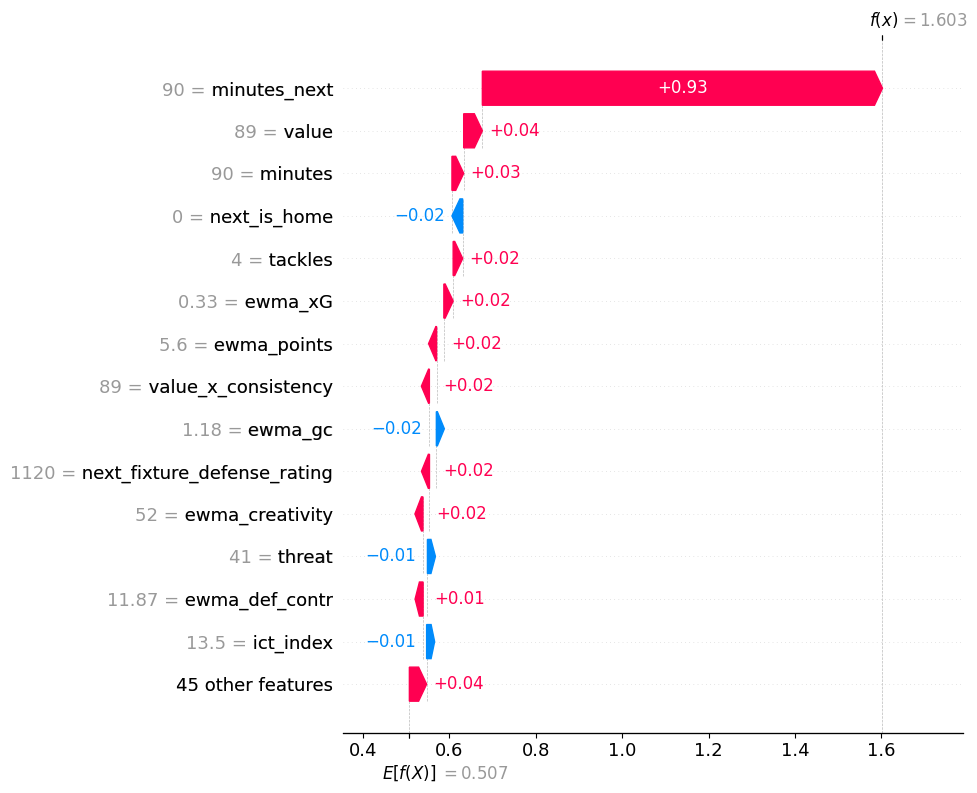

✅ Found 24 row(s) for 'Salah'

📊 M.Salah (Liverpool)
   Position: MID
   Predicted Points: 6.30
   Predicted Minutes: 79

🌊 Waterfall Plot: Points prediction for M.Salah


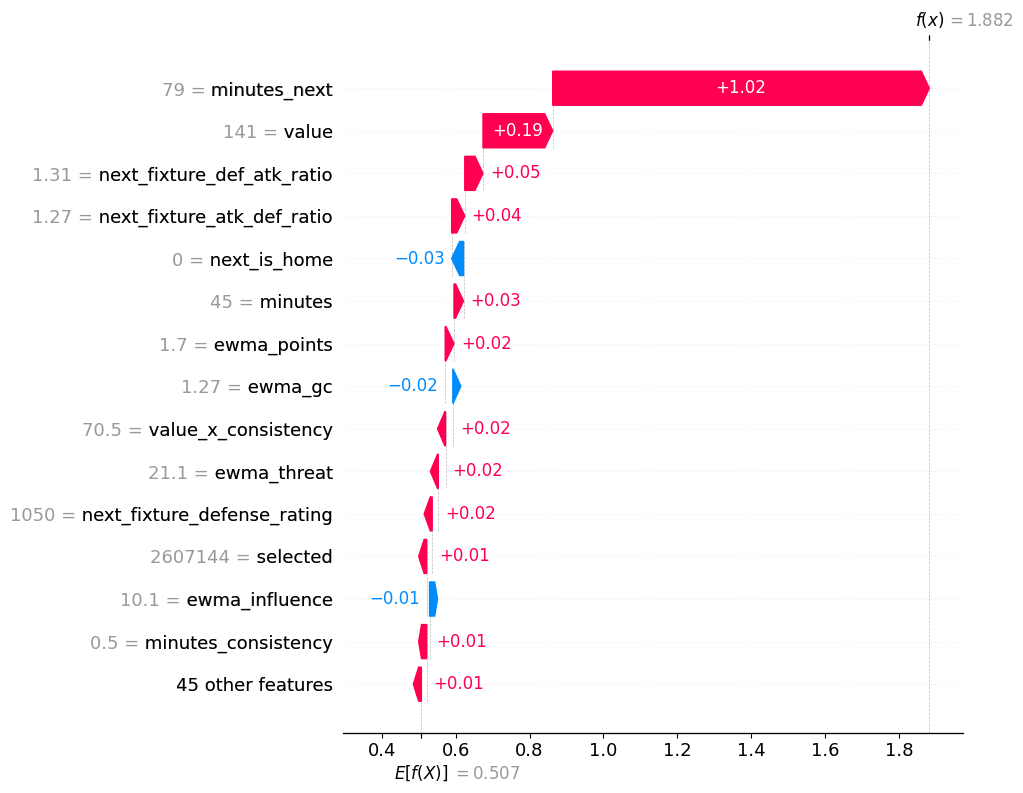

.values =
array([[ 1.32493904e-05,  6.92269257e-05,  4.00617114e-04,
        -1.12864444e-05, -5.76784516e-05, -3.05936924e-03,
        -1.86150122e-04, -4.22552031e-04, -7.65814977e-04,
        -2.53895890e-04,  6.43562015e-03,  2.59874725e-04,
         5.49034025e-06,  4.27702658e-04, -7.15620347e-04,
         2.58585382e-02,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.72490957e-03,  4.89626401e-06,
        -2.45958259e-03, -1.22287903e-04,  1.49305667e-02,
        -1.19104649e-03, -1.47254920e-05, -4.51273292e-03,
         3.93564704e-04,  4.46127794e-03,  1.88709224e-01,
        -6.65312402e-05,  2.38791009e-02, -6.92167995e-04,
         1.33562840e-03,  4.42807289e-04,  0.00000000e+00,
         1.90763203e-03,  1.94695978e-02,  6.44606818e-03,
        -7.85518721e-03, -4.32415121e-03, -4.33848996e-04,
        -2.07318018e-02, -2.36714900e-03,  5.87325470e-03,
        -3.06867010e-04, -1.64936921e-04, -2.11682065e-03,
         5.74270015e-03,  7.82186597e-03,  1.9

In [ ]:
import shap

def explain_player_prediction(player_name, model, model_type='points', max_display=15):
    """
    Explain a player's prediction using SHAP values.
    
    Args:
        player_name: Name of the player to explain (case-insensitive, partial match)
        model: The model (stacking ensemble for points, or LGBMRegressor for minutes)
        model_type: 'points' for stacking model, 'minutes' for minutes regressor
        max_display: Maximum number of features to display (default: 15)
    """
    shap.initjs()
    
    # Get the base model based on type
    if model_type == 'points':
        # For stacking ensemble, extract base model
        base_model = model.named_estimators_['lgbm_huber']
        # Load feature order for points model
        feature_cols = joblib.load("data/saved_models/feature_order.pkl")
    else:
        # For minutes model, use it directly
        base_model = model
        # Load feature order for minutes model
        feature_cols = joblib.load("data/saved_models/minutes_feature_order.pkl")
    
    # Create SHAP explainer for tree-based models
    explainer = shap.TreeExplainer(base_model)
    
    # Find player's row
    player_mask = identifiers_df['name'].str.contains(player_name, case=False)
    player_indices = identifiers_df[player_mask].index
    
    if len(player_indices) > 0:
        print(f"✅ Found {len(player_indices)} row(s) for '{player_name}'")
        
        # Get player data
        player_idx = player_indices[0]
        player_info = identifiers_df.loc[player_idx]
        
        # Prepare features based on model type
        if model_type == 'points':
            # Use the existing features_for_prediction DataFrame
            player_row = features_for_prediction.loc[player_idx:player_idx]
            player_pred_idx = features_for_prediction.index.get_loc(player_idx)
            predicted_value = predicted_points[player_pred_idx]
        else:
            # For minutes model, need to get the right features from rows_to_predict
            # Get the row before minutes were predicted
            player_features = rows_to_predict.loc[player_idx:player_idx]
            # Select only the features the minutes model expects
            player_row = player_features[feature_cols]
            # Get predicted minutes from the predicted_minutes DataFrame
            predicted_value = predicted_minutes[predicted_minutes['name'] == player_info['name']]['predicted_minutes'].iloc[0]
        
        print(f"\n📊 {player_info['name']} ({player_info['team']})")
        print(f"   Position: {player_info['position']}")
        
        if model_type == 'points':
            print(f"   Predicted Points: {predicted_value:.2f}")
            print(f"   Predicted Minutes: {player_info['minutes_next']:.0f}")
        else:
            print(f"   Predicted Minutes: {predicted_value:.0f}")
        
        # Calculate SHAP values
        shap_values = explainer(player_row)
        
        # Waterfall plot - shows how each feature contributes to the prediction
        metric = "Points" if model_type == 'points' else "Minutes"
        print(f"\n🌊 Waterfall Plot: {metric} prediction for {player_info['name']}")
        shap.plots.waterfall(shap_values[0], max_display=max_display)
        
        return shap_values
    else:
        print(f"❌ No player found matching '{player_name}'")
        return None



explain_player_prediction("B.Fernandes", points_model, model_type='points', max_display=15)
explain_player_prediction("Salah", points_model, model_type='points', max_display=15)


# minutes_model = joblib.load("data/saved_models/minutes_classifier_model.pkl")
# explain_player_prediction("Saka", minutes_model, model_type='minutes', max_display=15)